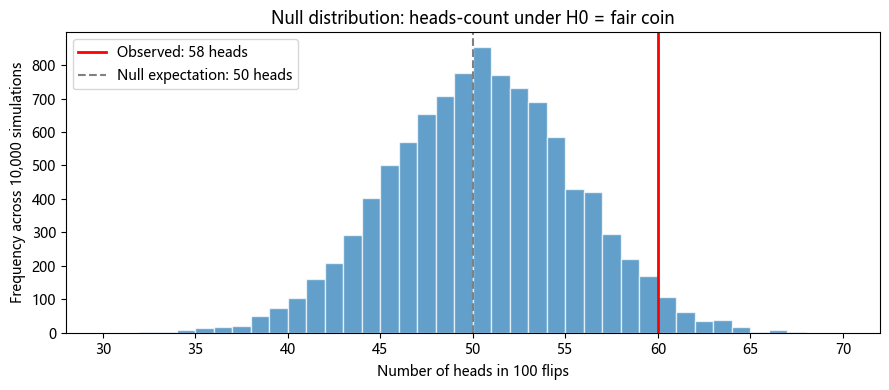

Observed: 61 heads out of 100
Simulated two-tailed p-value: 0.0351
scipy binomtest p-value:      0.0352


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# The null: the coin is fair. So each flip is 0 or 1 with probability 0.5.
# The test statistic: number of heads in 100 flips.
# We simulate the null distribution by flipping 100 coins, 10,000 times.

np.random.seed(42)
n_flips = 100
n_simulations = 10000

# Each row is one "experiment" of 100 flips. Sum across rows = heads per experiment.
simulated_experiments = np.random.choice([0, 1], size=(n_simulations, n_flips))
heads_per_experiment = simulated_experiments.sum(axis=1)

# This is your null distribution. Look at it.
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(heads_per_experiment, bins=range(30, 71), edgecolor='white', alpha=0.7)
ax.axvline(60, color='red', linewidth=2, label='Observed: 58 heads')
ax.axvline(50, color='gray', linestyle='--', label='Null expectation: 50 heads')
ax.set_xlabel('Number of heads in 100 flips')
ax.set_ylabel('Frequency across 10,000 simulations')
ax.set_title('Null distribution: heads-count under H0 = fair coin')
ax.legend()
plt.tight_layout()
plt.show()

# The observed value: 58 heads.
observed = 61

# Two-tailed p-value: fraction of simulations at least as extreme
# in either direction as the observed. "At least as extreme" here
# means distance from the null expectation (50) of >= 8.
distance = abs(observed - 50)
p_value_simulated = np.mean(abs(heads_per_experiment - 50) >= distance)

print(f"Observed: {observed} heads out of 100")
print(f"Simulated two-tailed p-value: {p_value_simulated:.4f}")

# Compare to the closed-form answer from scipy:
from scipy.stats import binomtest
result = binomtest(observed, n_flips, p=0.5, alternative='two-sided')
print(f"scipy binomtest p-value:      {result.pvalue:.4f}")

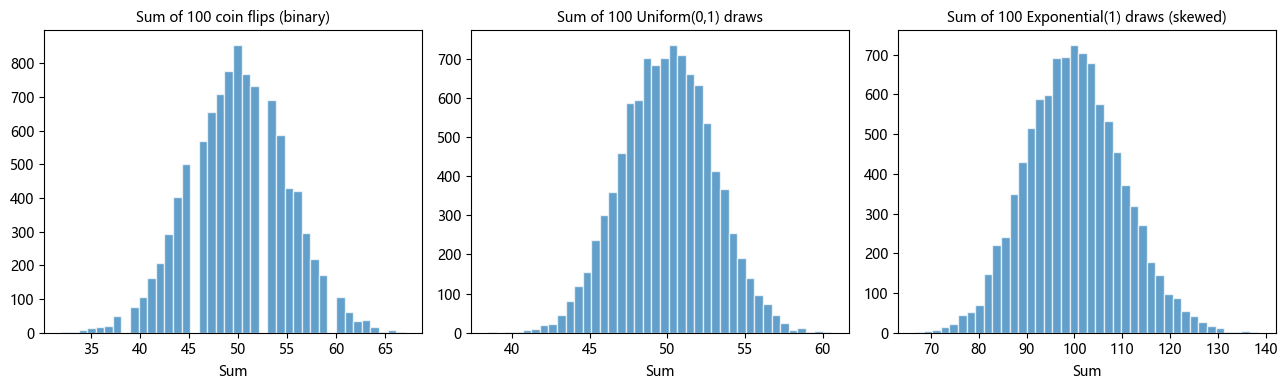

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
n_sims = 10000
n_samples = 100  # how many things we sum in each experiment

# Three different "individual" distributions, all non-normal.
# Coin flip (binary), uniform 0-1, exponential (right-skewed).
coin_sums     = np.random.choice([0, 1], size=(n_sims, n_samples)).sum(axis=1)
uniform_sums  = np.random.uniform(0, 1, size=(n_sims, n_samples)).sum(axis=1)
exp_sums      = np.random.exponential(1.0, size=(n_sims, n_samples)).sum(axis=1)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, data, label in zip(
    axes,
    [coin_sums, uniform_sums, exp_sums],
    ['Sum of 100 coin flips (binary)',
     'Sum of 100 Uniform(0,1) draws',
     'Sum of 100 Exponential(1) draws (skewed)']
):
    ax.hist(data, bins=40, edgecolor='white', alpha=0.7)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel('Sum')

plt.tight_layout()
plt.show()

In [3]:
heads_per_experiment.shape

(10000,)

In [4]:
import itertools
import numpy as np
from math import comb

# Approach 1: enumerate all 2^10 = 1024 arrangements
n = 10
all_arrangements = list(itertools.product([0, 1], repeat=n))
head_counts = [sum(seq) for seq in all_arrangements]
print(f"Enumeration (all {len(all_arrangements)} arrangements for n={n}):")
for k in range(n+1):
    count = head_counts.count(k)
    print(f"  k={k}: {count} arrangements, P = {count/len(all_arrangements):.5f}")

# Approach 3: closed-form binomial coefficient
print(f"\nClosed-form (binomial coefficients) for n={n}:")
for k in range(n+1):
    c = comb(n, k)
    p = c / 2**n
    print(f"  k={k}: C(10,{k}) = {c}, P = {p:.5f}")

Enumeration (all 1024 arrangements for n=10):
  k=0: 1 arrangements, P = 0.00098
  k=1: 10 arrangements, P = 0.00977
  k=2: 45 arrangements, P = 0.04395
  k=3: 120 arrangements, P = 0.11719
  k=4: 210 arrangements, P = 0.20508
  k=5: 252 arrangements, P = 0.24609
  k=6: 210 arrangements, P = 0.20508
  k=7: 120 arrangements, P = 0.11719
  k=8: 45 arrangements, P = 0.04395
  k=9: 10 arrangements, P = 0.00977
  k=10: 1 arrangements, P = 0.00098

Closed-form (binomial coefficients) for n=10:
  k=0: C(10,0) = 1, P = 0.00098
  k=1: C(10,1) = 10, P = 0.00977
  k=2: C(10,2) = 45, P = 0.04395
  k=3: C(10,3) = 120, P = 0.11719
  k=4: C(10,4) = 210, P = 0.20508
  k=5: C(10,5) = 252, P = 0.24609
  k=6: C(10,6) = 210, P = 0.20508
  k=7: C(10,7) = 120, P = 0.11719
  k=8: C(10,8) = 45, P = 0.04395
  k=9: C(10,9) = 10, P = 0.00977
  k=10: C(10,10) = 1, P = 0.00098


Observed sample mean: -0.000036
Observed sample std:  0.014491
Sample size:          250


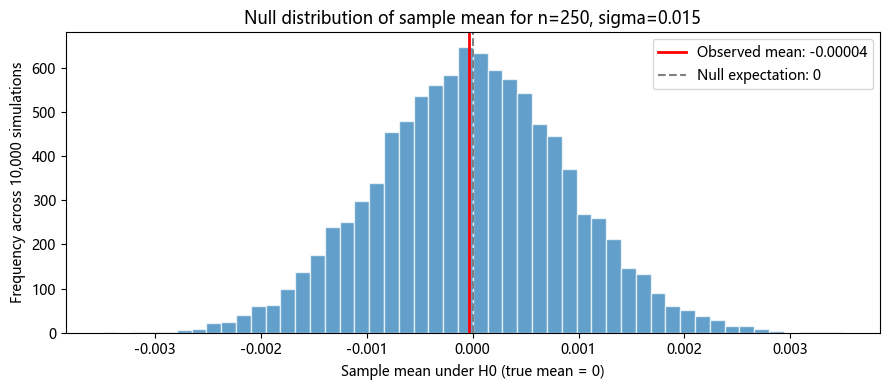


Simulated p-value:  0.9660
scipy t-test p-value: 0.9684
scipy t-statistic:    -0.0397


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)

# Generate a "year" of daily returns with TRUE mean = 0 and sigma = 0.015.
# By construction, the null hypothesis is true here.
n_days = 250
true_sigma = 0.015
returns = np.random.normal(loc=0.0, scale=true_sigma, size=n_days)

observed_mean = returns.mean()
observed_sigma = returns.std(ddof=1)  # ddof=1 for sample std
n = len(returns)

print(f"Observed sample mean: {observed_mean:.6f}")
print(f"Observed sample std:  {observed_sigma:.6f}")
print(f"Sample size:          {n}")

# Simulate the null distribution of the sample mean.
# Under H0: true mean = 0. Each simulation draws 250 returns from
# Normal(0, observed_sigma) and records the sample mean.
n_simulations = 10000
null_means = np.empty(n_simulations)
for i in range(n_simulations):
    simulated_returns = np.random.normal(loc=0.0, scale=observed_sigma, size=n)
    null_means[i] = simulated_returns.mean()

# The null distribution. Plot it with the observed value marked.
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(null_means, bins=50, edgecolor='white', alpha=0.7)
ax.axvline(observed_mean, color='red', linewidth=2,
           label=f'Observed mean: {observed_mean:.5f}')
ax.axvline(0, color='gray', linestyle='--', label='Null expectation: 0')
ax.set_xlabel('Sample mean under H0 (true mean = 0)')
ax.set_ylabel('Frequency across 10,000 simulations')
ax.set_title('Null distribution of sample mean for n=250, sigma=0.015')
ax.legend()
plt.tight_layout()
plt.show()

# Two-tailed p-value: fraction of simulations with |mean| >= |observed|.
p_value_simulated = np.mean(np.abs(null_means) >= np.abs(observed_mean))

# Compare to scipy's one-sample t-test against popmean=0.
t_stat, p_value_ttest = stats.ttest_1samp(returns, popmean=0.0)

print(f"\nSimulated p-value:  {p_value_simulated:.4f}")
print(f"scipy t-test p-value: {p_value_ttest:.4f}")
print(f"scipy t-statistic:    {t_stat:.4f}")

In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Try to load cached data. If missing, pull fresh via baostock.
CSV_PATH = 'data/sz000001_with_returns.csv'

if os.path.exists(CSV_PATH):
    df = pd.read_csv(CSV_PATH, index_col='date', parse_dates=True)
    print(f"Loaded from cache: {CSV_PATH}, {len(df)} rows")
else:
    # Pull fresh. Assumes utils.py is in the project folder.
    from utils import get_stock_data
    df = get_stock_data('sz.000001', '2024-01-01', '2024-12-31')
    # Compute simple returns if not already in df
    if 'simple_returns' not in df.columns:
        df['simple_returns'] = df['close'].pct_change()
    os.makedirs('data', exist_ok=True)
    df.to_csv(CSV_PATH)
    print(f"Pulled fresh and cached: {CSV_PATH}, {len(df)} rows")

print(df.head())
print(df.columns.tolist())

Loaded from cache: data/sz000001_with_returns.csv, 242 rows
                open      high       low     close     volume        amount  \
date                                                                          
2024-01-02  8.143365  8.169382  7.987262  7.987262  115836645  1.075742e+09   
2024-01-03  7.969917  7.995934  7.935228  7.978590   73361031  6.736736e+08   
2024-01-04  7.969917  7.969917  7.874521  7.900538   86419399  7.874701e+08   
2024-01-05  7.891866  8.186727  7.865849  8.039296  199162216  1.852660e+09   
2024-01-08  8.004607  8.065313  7.900538  7.935228  112115619  1.029007e+09   

            pctChg  simple_returns  
date                                
2024-01-02 -1.9169             NaN  
2024-01-03 -0.1086       -0.001086  
2024-01-04 -0.9783       -0.009783  
2024-01-05  1.7563        0.017563  
2024-01-08 -1.2945       -0.012945  
['open', 'high', 'low', 'close', 'volume', 'amount', 'pctChg', 'simple_returns']


平安银行 2024 (sz.000001)
  Sample size:   241 trading days
  Observed mean: 0.001504  (0.150% per day)
  Observed std:  0.016473  (1.647% per day)
  Annualized mean ≈ 36.39%
  Annualized std  ≈ 25.63%

  Standard error of mean: 0.001061
  Observed / SEM (t-statistic): 1.4172

  Simulated p-value:   0.1515
  scipy t-test p-value: 0.1577
  scipy t-statistic:    1.4172


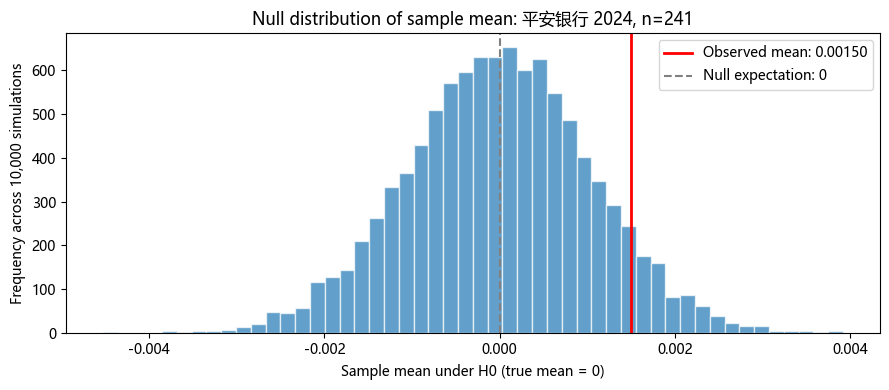

In [7]:
# Pull the returns and drop the NaN first row.
returns = df['simple_returns'].dropna().values

observed_mean = returns.mean()
observed_sigma = returns.std(ddof=1)
n = len(returns)

print(f"平安银行 2024 (sz.000001)")
print(f"  Sample size:   {n} trading days")
print(f"  Observed mean: {observed_mean:.6f}  ({observed_mean*100:.3f}% per day)")
print(f"  Observed std:  {observed_sigma:.6f}  ({observed_sigma*100:.3f}% per day)")
print(f"  Annualized mean ≈ {observed_mean * 242 * 100:.2f}%")
print(f"  Annualized std  ≈ {observed_sigma * np.sqrt(242) * 100:.2f}%")

# Null hypothesis: true daily expected return is zero.
# Simulate 10,000 parallel universes where the null is true.
np.random.seed(42)
n_simulations = 10000
null_means = np.empty(n_simulations)
for i in range(n_simulations):
    simulated = np.random.normal(loc=0.0, scale=observed_sigma, size=n)
    null_means[i] = simulated.mean()

# Standard error of the mean, for reference.
sem = observed_sigma / np.sqrt(n)

# Two-tailed p-value from simulation.
p_sim = np.mean(np.abs(null_means) >= np.abs(observed_mean))

# Parametric comparison via scipy.
from scipy import stats
t_stat, p_ttest = stats.ttest_1samp(returns, popmean=0.0)

print(f"\n  Standard error of mean: {sem:.6f}")
print(f"  Observed / SEM (t-statistic): {observed_mean / sem:.4f}")
print(f"\n  Simulated p-value:   {p_sim:.4f}")
print(f"  scipy t-test p-value: {p_ttest:.4f}")
print(f"  scipy t-statistic:    {t_stat:.4f}")

# Visual: null distribution with observed value marked.
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(null_means, bins=50, edgecolor='white', alpha=0.7)
ax.axvline(observed_mean, color='red', linewidth=2,
           label=f'Observed mean: {observed_mean:.5f}')
ax.axvline(0, color='gray', linestyle='--', label='Null expectation: 0')
ax.set_xlabel('Sample mean under H0 (true mean = 0)')
ax.set_ylabel('Frequency across 10,000 simulations')
ax.set_title(f'Null distribution of sample mean: 平安银行 2024, n={n}')
ax.legend()
plt.tight_layout()
plt.show()

In [8]:
from matplotlib import font_manager
chinese_fonts = [f.name for f in font_manager.fontManager.ttflist
                 if any(kw in f.name for kw in ['YaHei', 'SimHei', 'SimSun', 'Microsoft JhengHei'])]
print("Available Chinese fonts:", sorted(set(chinese_fonts)))

Available Chinese fonts: ['Microsoft JhengHei', 'Microsoft YaHei', 'SimHei', 'SimSun', 'SimSun-ExtB', 'SimSun-ExtG']


In [9]:
import matplotlib
print(matplotlib.get_configdir())

C:\Users\Leo\.matplotlib


In [10]:
import matplotlib
from pathlib import Path

config_dir = Path(matplotlib.get_configdir())
rc_path = config_dir / "matplotlibrc"

contents = """font.sans-serif: Microsoft YaHei, DejaVu Sans
axes.unicode_minus: False
"""

rc_path.write_text(contents, encoding='utf-8')
print(f"Wrote {rc_path}")
print(f"File exists: {rc_path.exists()}")
print(f"File size: {rc_path.stat().st_size} bytes")
print("\nContents:")
print(rc_path.read_text(encoding='utf-8'))

Wrote C:\Users\Leo\.matplotlib\matplotlibrc
File exists: True
File size: 74 bytes

Contents:
font.sans-serif: Microsoft YaHei, DejaVu Sans
axes.unicode_minus: False



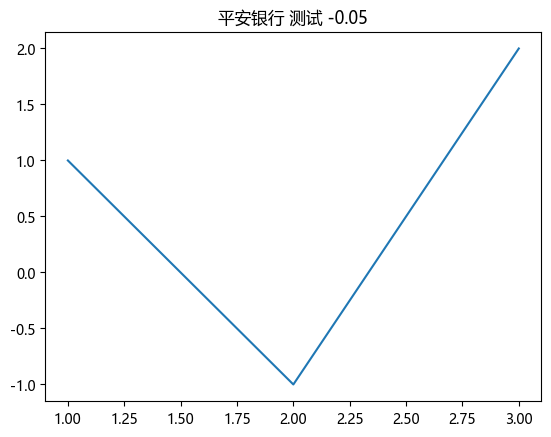

In [11]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ax.set_title('平安银行 测试 -0.05')
ax.plot([1, 2, 3], [1, -1, 2])
plt.show()

Number of (yesterday, today) pairs: 240

Observed lag-1 autocorrelation: -0.0505
scipy parametric p-value:       0.4362
Permutation p-value:            0.4224


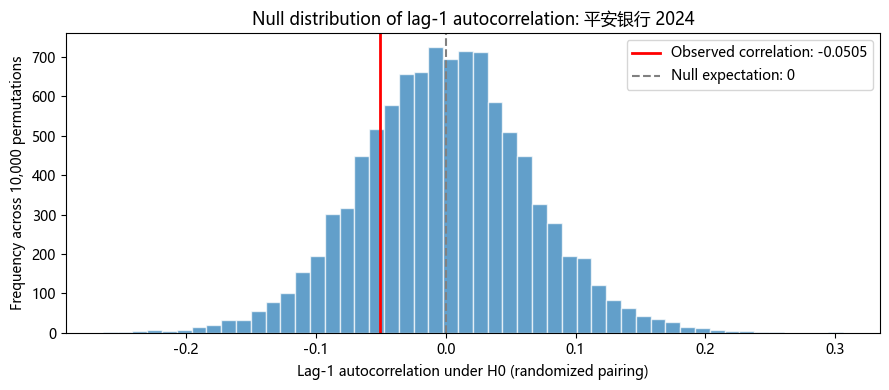


Null distribution diagnostics:
  Mean of null correlations:     -0.00053  (should be near 0)
  Std of null correlations:      0.0652  (theoretical: 0.0645)


In [12]:
# Pair each day with the next day's return. x = yesterday, y = today.
returns_series = df['simple_returns'].dropna().values
x = returns_series[:-1]  # all days except the last
y = returns_series[1:]   # all days except the first

n_pairs = len(x)
print(f"Number of (yesterday, today) pairs: {n_pairs}")

# Observed lag-1 autocorrelation.
from scipy.stats import pearsonr
observed_corr, p_parametric = pearsonr(x, y)
print(f"\nObserved lag-1 autocorrelation: {observed_corr:.4f}")
print(f"scipy parametric p-value:       {p_parametric:.4f}")

# Permutation test: shuffle y, recompute correlation, 10,000 times.
# This builds the null distribution of what correlation values
# would look like if the pairing between yesterday and today were random.
np.random.seed(42)
n_permutations = 10000
null_corrs = np.empty(n_permutations)
for i in range(n_permutations):
    y_shuffled = np.random.permutation(y)
    null_corrs[i] = np.corrcoef(x, y_shuffled)[0, 1]

# Two-tailed p-value from permutation.
p_permutation = np.mean(np.abs(null_corrs) >= np.abs(observed_corr))
print(f"Permutation p-value:            {p_permutation:.4f}")

# Plot: null distribution with observed value marked.
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(null_corrs, bins=50, edgecolor='white', alpha=0.7)
ax.axvline(observed_corr, color='red', linewidth=2,
           label=f'Observed correlation: {observed_corr:.4f}')
ax.axvline(0, color='gray', linestyle='--', label='Null expectation: 0')
ax.set_xlabel('Lag-1 autocorrelation under H0 (randomized pairing)')
ax.set_ylabel('Frequency across 10,000 permutations')
ax.set_title('Null distribution of lag-1 autocorrelation: 平安银行 2024')
ax.legend()
plt.tight_layout()
plt.show()

# Diagnostic: verify the null distribution behaves correctly.
print(f"\nNull distribution diagnostics:")
print(f"  Mean of null correlations:     {null_corrs.mean():+.5f}  (should be near 0)")
print(f"  Std of null correlations:      {null_corrs.std():.4f}  (theoretical: {1/np.sqrt(n_pairs):.4f})")